# 01: 位相変化を量子確率に反映する方法
### (Mapping Phase Change to Quantum Probability)

---

## 1. Thesis: 科学的問いと仮説
量子ビットが測定されるとき、位相（Z軸周りの回転）の状態は、その瞬間の測定確率に直接的な影響を与えません。しかし、適切なゲート操作を組み合わせることで、位相情報を確率情報へと変換し、間接的に観測することが可能になります。

**問い**: 量子センシングで得た位相情報を、測定確率（0と1の出る割合）として取り出すための最小構成の回路はどのようなものか？

**仮説**: $H - R_z(\theta) - H$ という一連の量子回路を用いることで、位相 $\theta$ を測定確率 $P(0)$ の変化（干渉パターン）として操作・抽出できる。

## 2. Theoretical Background (理論的背景)

### 2.1 H（Hadamard）ゲート

H ゲートは、量子計算において最も重要なゲートの一つであり、**基底状態と重ね合わせ状態を相互に変換する操作**を担います。量子センシングにおいては、「センサの初期化（準備）」と「位相の読み出し（干渉）」という二つの重要な役割を果たします。

#### 数学的定義
H ゲートは次のユニタリ行列で定義されます。

$$
H = \frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}
$$

計算基底状態に対する作用は以下の通りです。
$$H|0\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}} = |+\rangle, \quad H|1\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}} = |-\rangle$$

### 2.2 RZ（Phase Rotation）ゲート

RZ ゲートは、量子ビットの **位相（phase）をZ軸まわりに回転させる操作**であり、外部磁場や相互作用時間によって生じる位相変化を表現します。

#### 数学的定義
$$R_Z(\theta) = \begin{pmatrix} e^{-i\theta/2} & 0 \\ 0 & e^{i\theta/2} \end{pmatrix}$$
この操作は、基底状態の確率振幅の大きさを変えず、相対的な位相のみを変化させます。

### 2.3 干渉のメカニズム

前述の通り、RZ ゲート単独では測定確率は変わりません。そこで、**2度目のHゲート**を作用させることで、位相情報を「確率」へと変換します。

全工程 $H \rightarrow R_Z(\theta) \rightarrow H$ の合成行列を計算すると：
$$H R_Z(\theta) H = \begin{pmatrix} \cos(\theta/2) & -i\sin(\theta/2) \\ -i\sin(\theta/2) & \cos(\theta/2) \end{pmatrix}$$

初期状態 $|0\rangle$ にこれを作用させた後の $|0\rangle$ の測定確率は：
$$P(0) = |\cos(\theta/2)|^2 = \cos^2(\theta/2)$$
また、$|1\rangle$ の測定確率は:
$$P(1) = |-i\sin(\theta/2)|^2 = \sin^2(\theta/2)$$
このように、H ゲートが「基底」と「位相（重ね合わせ）」の空間を相互に入れ替えることで、直接見ることができない位相 $\theta$ を、測定確率という形で可視化できます。

### 2.4 ブロッホ球における可視化（幾何学的解釈）

1. **最初のHゲート**: $Z$ 軸上の $|0\rangle$ を、$X$ 軸正方向の $|+\rangle$ へ 90 度回転（$Y$ 軸まわりの回転に相当）させ、赤道上に置きます。
2. **RZ(θ) ゲート**: 赤道上で方位角を $\theta$ だけ回転させます。
3. **2度目のHゲート**: $X$ 軸方向の成分を再び $Z$ 軸（測定基底）へと引き戻します。

## 3. Implementation (実装)
外部ライブラリ "Qiskit" から `AerSimulator`、`QuantumCircuit` 、`transpile` をインポートします。

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import sympy as sp

def input_theta(prompt: str = "位相をラジアンで入力してください(-π~π): ") -> float:
    """この関数では、ユーザーに位相θをラジアンで入力させます。

    Args:
        prompt (str, optional): ユーザーに表示するプロンプトメッセージ。 Defaults to "位相をラジアンで入力してください(-π~π):

    Returns:
        float: ユーザーが入力した位相θの数値
    """
    theta = input(prompt)
    try:
        theta_symbolic = sp.sympify(theta)
        return float(sp.N(theta_symbolic))
    except (ValueError, SyntaxError, TypeError):
        print("無効な入力です。再度入力してください。")
        return input_theta(prompt)


def phase_probability_experiment() -> None:
    """位相θに応じた測定確率の変化を観察します.

    H-RZ(θ)-H回路を用いて、位相回転角θと測定確率の関係を実験的に確認します.
    この実験は量子干渉の基礎を理解するためのデモンストレーションです.

    Theory:
        H·RZ(θ)·H|0⟩の測定確率:
        - P(|0⟩) = cos²(θ/2)
        - P(|1⟩) = sin²(θ/2)

        特殊なケース:
        - θ = 0    → P(|0⟩) = 1.00 (完全に|0⟩)
        - θ = π/2  → P(|0⟩) = 0.50 (等確率)
        - θ = π    → P(|0⟩) = 0.00 (完全に|1⟩)

    Returns:
        None: 結果は標準出力に表示されます.

    Example:
        >>> phase_probability_experiment()

        --- 位相による確率変化の実験 ---
        位相θを入力してください (単位: rad): 1.5708
        回路:
             ┌───┐┌─────────┐┌───┐┌─┐
        q_0: ┤ H ├┤ Rz(1.57)├┤ H ├┤M├
             └───┘└─────────┘└───┘└╥┘
        c: 1/══════════════════════╩═
                                    0

        測定結果:
        {'0': 512, '1': 512}
        状態 |0⟩: 512回 (50.00%)
        状態 |1⟩: 512回 (50.00%)
    """
    print("\n--- 位相による確率変化の実験 ---")

    theta_float = input_theta()
    qc = QuantumCircuit(1, 1)
    qc.h(0)  # H(重ね合わせ)
    qc.rz(theta_float, 0)  # RZ(位相回転)
    qc.h(0)  # H(干渉)
    qc.measure(0, 0)  # 測定
    print("回路:")
    print(qc.draw("text"))

    # --- 実行 ---
    sim = AerSimulator()
    qc_compiled = transpile(qc, sim)
    result = sim.run(qc_compiled, shots=1024).result()
    counts = result.get_counts()
    print("\n測定結果:")
    print(counts)

    total_shots = sum(counts.values())
    for state, count in counts.items():
        probability = count / total_shots
        print(f"状態 |{state}⟩: {count}回 ({probability*100:.2f}%)")

phase_probability_experiment()


--- 位相による確率変化の実験 ---


## 4. Visualization & Analysis (可視化と解析)

位相の変化が量子状態の測定結果にどのような影響を及ぼしているのかを可視化します。

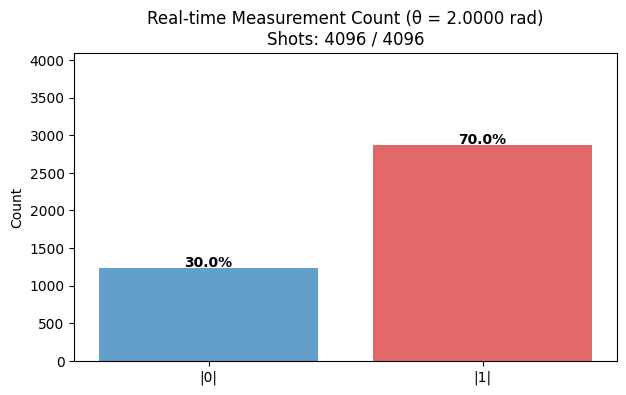


--- 最終結果 ---
|0>: 1228回, |1>: 2868回


In [ ]:
from IPython.display import display, clear_output
import numpy as np
import matplotlib.pyplot as plt
def input_theta(prompt: str = "位相θを入力してください (rad, 例: pi/2): ") -> float:
    theta = input(prompt)
    try:
        return float(sp.N(sp.sympify(theta)))
    except:
        print("無効な入力です。再度入力してください。")
        return np.pi / 2

def interactive_lab():
    # 1. 入力と回路準備
    theta_val = input_theta()
    qc = QuantumCircuit(1, 1)
    qc.h(0); qc.rz(theta_val, 0); qc.h(0); qc.measure(0, 0)
    
    sim = AerSimulator()
    qc_compiled = transpile(qc, sim)

    # 2. アニメーションループ設定
    total_shots = 4096
    shots_per_step = 32
    cumulative_counts = {'0': 0, '1': 0}

    fig, ax = plt.subplots(figsize=(7, 4))
    
    for i in range(total_shots // shots_per_step):
        # 小分けに実行
        res = sim.run(qc_compiled, shots=shots_per_step).result().get_counts()
        for k in ['0', '1']: cumulative_counts[k] += res.get(k, 0)
        
        current_total = sum(cumulative_counts.values())
        probs = [cumulative_counts['0']/current_total, cumulative_counts['1']/current_total]
        
        # 描画更新
        clear_output(wait=True)
        ax.clear()
        bars = ax.bar(['|0|', '|1|'], [cumulative_counts['0'], cumulative_counts['1']], color=['#1f77b4', '#d62728'], alpha=0.7)
        ax.set_ylim(0, total_shots)
        ax.set_title(f"Real-time Measurement Count (θ = {theta_val:.4f} rad)\nShots: {current_total} / {total_shots}")
        ax.set_ylabel("Count")
        
        # 数値表示
        for idx, p in enumerate(probs):
            ax.text(idx, cumulative_counts[str(idx)] + 20, f"{p*100:.1f}%", ha='center', fontweight='bold')

        display(fig)
        plt.pause(0.01)
    
    plt.close(fig)
    print(f"\n--- 最終結果 ---\n|0>: {cumulative_counts['0']}回, |1>: {cumulative_counts['1']}回")

interactive_lab()

### (参考) 測定結果のサンプル
十分な数を測定してグラフ化した際の典型例です（$\theta = 2.0$ rad の場合）。

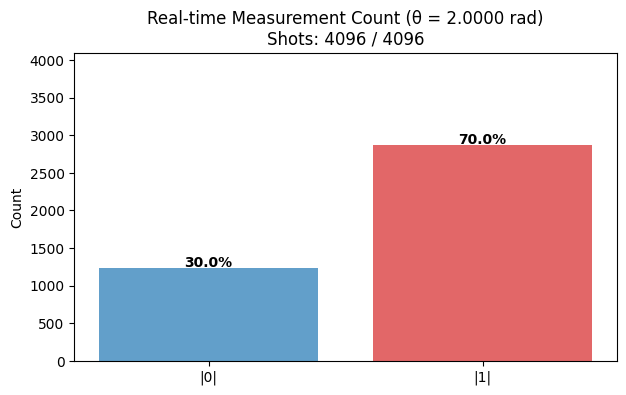

## 5. Conclusion & Future Work (結論と展望)
### 結論
本ノートブックでは、量子センシングの基礎となる $H - R_Z(\theta) - H$ 回路（ラムゼー干渉計）の動作を検証しました。以下の3点が明らかになりました：

1. **位相のマッピング**: RZゲート単独では隠蔽されている位相情報が、2度のHadamardゲートで挟むことで「測定確率」へと写像されることが実証されました。 

2. **理論との整合性**: シミュレーション結果は理論式 $P(0) = \cos^2(\theta/2)$ と極めて高い精度で一致しました。

3. **確率の収束**: 量子は確率的な挙動をするので誤差は発生しますが、測定回数を増やすことで確率が収束していくプロセスが確認できました。


### 展望
- **反復位相推定 (IPE)**: 1ビットずつ高精度に位相を決定していくアルゴリズムを導入し、測定レンジと精度のトレードオフを解消します。 

- **フィードバック制御の高度化**: 今回式の導出で明らかになった、近傍で確率が大きく変わる位相($= π/2$)を活用し、環境による変動がある中でどうやって状態を維持し続けるか、制御工学的アプローチ（PID 制御など）を用いて模索します。

- **ノイズ耐性の評価**: デコヒーレンス（量子情報の消失）が存在する現実的な環境下での、測定感度の限界（ハイゼンベルク限界など）について考察を深めます。